In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

SECOM_DATA_PATH   = r'C:\Users\ASUS\Downloads\capstone\Project\secom.data'
SECOM_LABELS_PATH = r'C:\Users\ASUS\Downloads\capstone\Project\secom_labels.data'
OUTPUT_DIR        = r'C:\Users\ASUS\Downloads\capstone\Project\outputs'

In [2]:
X_raw = pd.read_csv(SECOM_DATA_PATH, sep=' ', header=None)

labels = pd.read_csv(
    SECOM_LABELS_PATH,
    sep=' ',
    header=None,
    names=['label', 'timestamp']
)

y = labels['label']
timestamps = pd.to_datetime(
    labels['timestamp'],
    format='%d/%m/%Y %H:%M:%S'
)

print(f"Features shape   : {X_raw.shape}")
print(f"Labels shape     : {labels.shape}")
print(f"\nClass Distribution:")
print(f"  Pass (-1)  : {(y == -1).sum()}")
print(f"  Fail (+1)  : {(y ==  1).sum()}")
print(f"  Fail rate  : {(y ==  1).mean():.2%}")
print(f"  NaN count  : {X_raw.isnull().sum().sum()}")

Features shape   : (1567, 590)
Labels shape     : (1567, 2)

Class Distribution:
  Pass (-1)  : 1463
  Fail (+1)  : 104
  Fail rate  : 6.64%
  NaN count  : 41951


In [3]:
missing_pct = X_raw.isnull().mean() * 100

print(f"Features with ANY missing  : {(missing_pct > 0).sum()}")
print(f"Features with >50% missing : {(missing_pct > 50).sum()}")
print(f"Features with >90% missing : {(missing_pct > 90).sum()}")
print(f"Features with 100% missing : {(missing_pct == 100).sum()}")

print(f"\nTop 10 most missing features:")
print(missing_pct.sort_values(ascending=False).head(10).to_string())

Features with ANY missing  : 538
Features with >50% missing : 28
Features with >90% missing : 4
Features with 100% missing : 0

Top 10 most missing features:
292    91.193363
293    91.193363
158    91.193363
157    91.193363
492    85.577537
85     85.577537
358    85.577537
220    85.577537
244    64.964901
517    64.964901


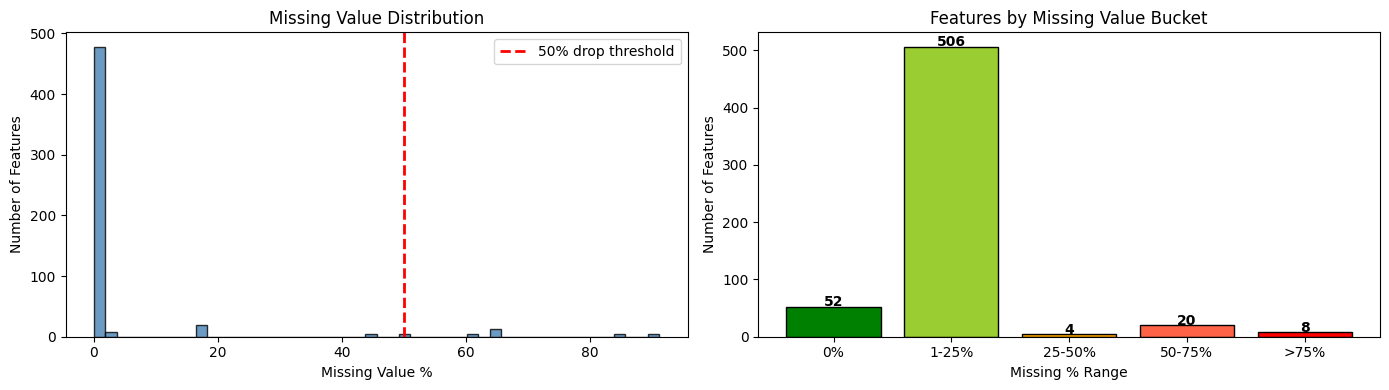

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(
    missing_pct[missing_pct > 0],
    bins=50, color='steelblue',
    edgecolor='black', alpha=0.8
)
axes[0].axvline(
    50, color='red', linestyle='--',
    linewidth=2, label='50% drop threshold'
)
axes[0].set_xlabel('Missing Value %')
axes[0].set_ylabel('Number of Features')
axes[0].set_title('Missing Value Distribution')
axes[0].legend()

buckets = {
    '0%':     (missing_pct == 0).sum(),
    '1-25%':  ((missing_pct > 0)  & (missing_pct <= 25)).sum(),
    '25-50%': ((missing_pct > 25) & (missing_pct <= 50)).sum(),
    '50-75%': ((missing_pct > 50) & (missing_pct <= 75)).sum(),
    '>75%':   (missing_pct > 75).sum()
}
bars = axes[1].bar(
    buckets.keys(), buckets.values(),
    color=['green','yellowgreen','orange','tomato','red'],
    edgecolor='black'
)
axes[1].set_xlabel('Missing % Range')
axes[1].set_ylabel('Number of Features')
axes[1].set_title('Features by Missing Value Bucket')
for i, v in enumerate(buckets.values()):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plots/p1_missing_analysis.png', dpi=150)
plt.show()


In [5]:
MISSING_THRESHOLD = 50
features_start = X_raw.shape[1]

cols_high_missing = missing_pct[
    missing_pct > MISSING_THRESHOLD
].index

X_step1 = X_raw.drop(columns=cols_high_missing)

print(f"Original features      : {features_start}")
print(f"Dropped (>50% missing) : {len(cols_high_missing)}")
print(f"Remaining              : {X_step1.shape[1]}")

Original features      : 590
Dropped (>50% missing) : 28
Remaining              : 562


In [6]:
MISSING_THRESHOLD = 50
features_start = X_raw.shape[1]

cols_high_missing = missing_pct[
    missing_pct > MISSING_THRESHOLD
].index

X_step1 = X_raw.drop(columns=cols_high_missing)

print(f"Original features      : {features_start}")
print(f"Dropped (>50% missing) : {len(cols_high_missing)}")
print(f"Remaining              : {X_step1.shape[1]}")

Original features      : 590
Dropped (>50% missing) : 28
Remaining              : 562


Dropped (variance < 0.01) : 265
Remaining                   : 297


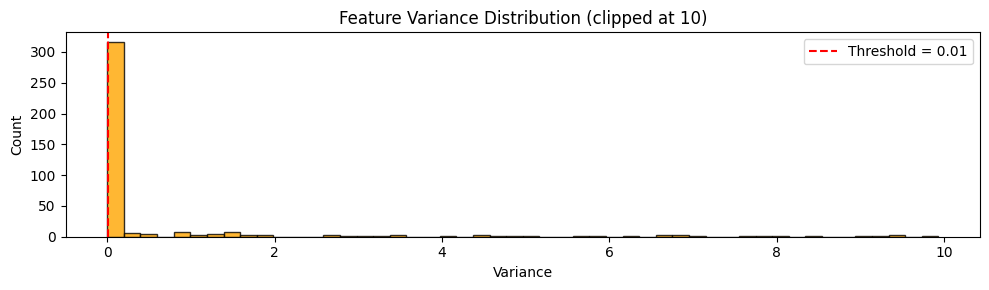

In [7]:
VARIANCE_THRESHOLD = 0.01
variance = X_step1.var()
cols_low_var = variance[variance < VARIANCE_THRESHOLD].index

X_step2 = X_step1.drop(columns=cols_low_var)

print(f"Dropped (variance < {VARIANCE_THRESHOLD}) : {len(cols_low_var)}")
print(f"Remaining                   : {X_step2.shape[1]}")

plt.figure(figsize=(10, 3))
plt.hist(
    variance[variance < 10],
    bins=50, color='orange',
    edgecolor='black', alpha=0.8
)
plt.axvline(
    VARIANCE_THRESHOLD, color='red',
    linestyle='--', label=f'Threshold = {VARIANCE_THRESHOLD}'
)
plt.xlabel('Variance')
plt.ylabel('Count')
plt.title('Feature Variance Distribution (clipped at 10)')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plots/p1_variance_distribution.png', dpi=150)
plt.show()

In [8]:
imp_temp = SimpleImputer(strategy='median')
X_temp = pd.DataFrame(
    imp_temp.fit_transform(X_step2),
    columns=X_step2.columns
)

CORR_THRESHOLD = 0.95
corr_matrix = X_temp.corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
cols_high_corr = [
    col for col in upper.columns
    if any(upper[col] > CORR_THRESHOLD)
]
X_step3 = X_step2.drop(columns=cols_high_corr)

print(f"Dropped (r > {CORR_THRESHOLD})    : {len(cols_high_corr)}")
print(f"Remaining                 : {X_step3.shape[1]}")
print(f"\n── Feature Reduction Summary ──")
print(f"  Original              : {features_start}")
print(f"  After missing drop    : {X_step1.shape[1]}")
print(f"  After variance drop   : {X_step2.shape[1]}")
print(f"  After corr drop       : {X_step3.shape[1]}")
print(f"  Total removed         : {features_start - X_step3.shape[1]}")

Dropped (r > 0.95)    : 102
Remaining                 : 195

── Feature Reduction Summary ──
  Original              : 590
  After missing drop    : 562
  After variance drop   : 297
  After corr drop       : 195
  Total removed         : 395


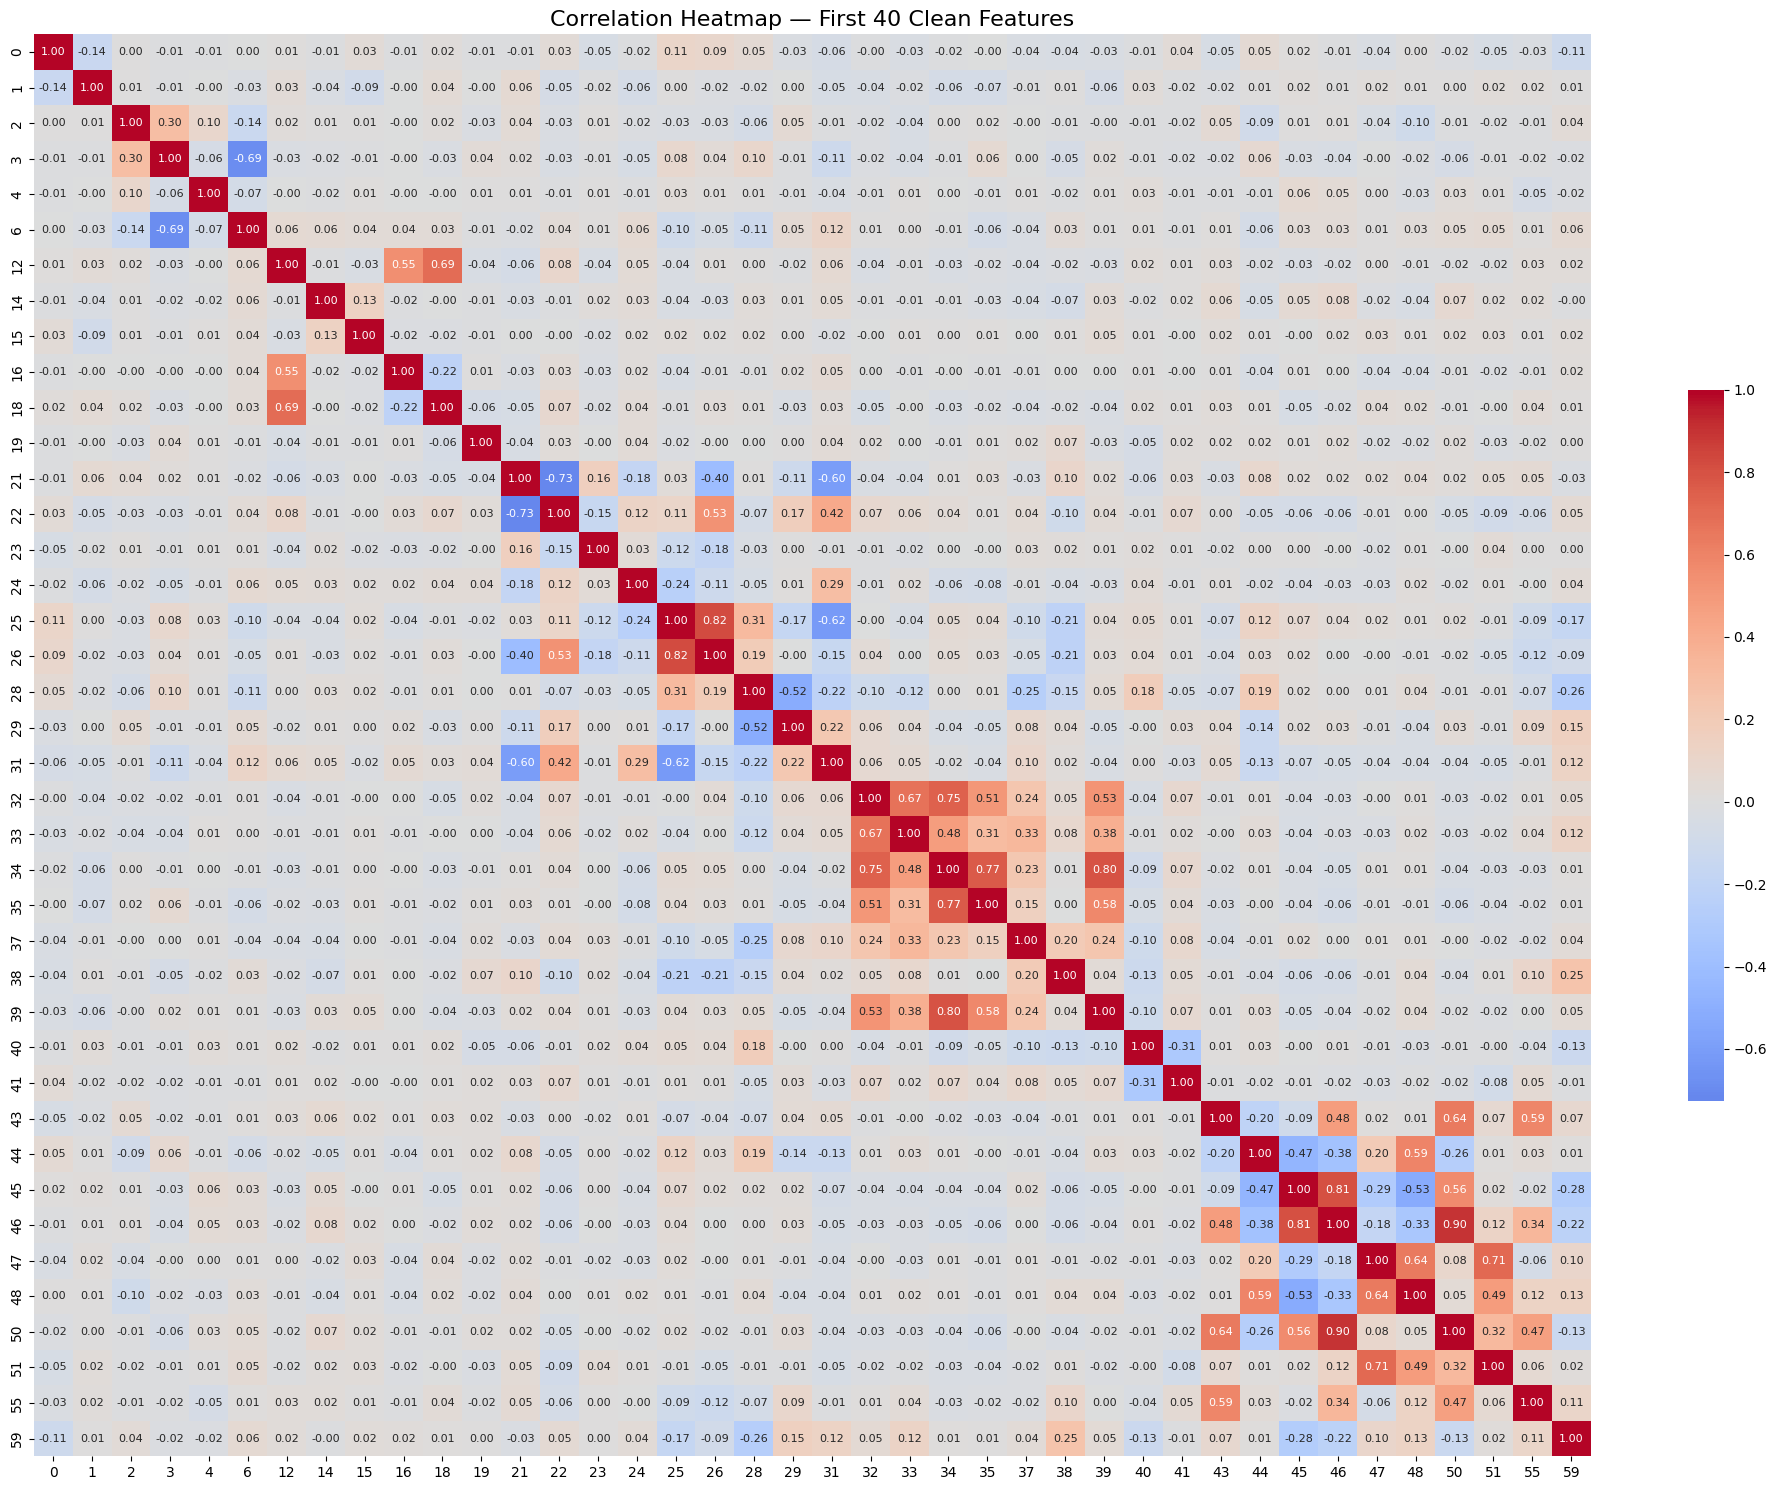

In [9]:
clean_cols = X_temp.drop(
    columns=cols_high_corr
).iloc[:, :40].columns

plt.figure(figsize=(20, 15)) # Increased size to accommodate numbers
sns.heatmap(
    X_temp[clean_cols].corr(),
    annot=True,              # This adds the numbers
    fmt=".2f",               # Limits to 2 decimal places
    annot_kws={"size": 8},   # Keeps font small so it fits in the cells
    cmap='coolwarm', center=0,
    xticklabels=True,        # Usually helpful if showing numbers
    yticklabels=True,
    cbar_kws={'shrink': 0.5}
)
plt.title('Correlation Heatmap — First 40 Clean Features', fontsize=16)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plots/p1_correlation_heatmap.png', dpi=150)
plt.show()


In [16]:

imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_step3),
    columns=X_step3.columns
)

print(f" Median imputation complete")
print(f"   NaNs before : {X_step3.isnull().sum().sum()}")
print(f"   NaNs after  : {X_imputed.isnull().sum().sum()}")
print(f"   Shape       : {X_imputed.shape}")

 Median imputation complete
   NaNs before : 4736
   NaNs after  : 0
   Shape       : (1567, 195)


In [17]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_imputed),
    columns=X_imputed.columns
)

print(f" StandardScaler complete")
print(f"   Shape             : {X_scaled.shape}")
print(f"   Mean (should ≈ 0) : {X_scaled.mean().mean():.8f}")
print(f"   Std  (should ≈ 1) : {X_scaled.std().mean():.6f}")

 StandardScaler complete
   Shape             : (1567, 195)
   Mean (should ≈ 0) : -0.00000000
   Std  (should ≈ 1) : 1.000319


In [18]:
sort_idx  = timestamps.argsort().values
X_sorted  = X_scaled.iloc[sort_idx].reset_index(drop=True)
y_sorted  = y.iloc[sort_idx].reset_index(drop=True)
ts_sorted = timestamps.iloc[sort_idx].reset_index(drop=True)

split_point = int(len(X_sorted) * 0.80)

X_train  = X_sorted.iloc[:split_point].reset_index(drop=True)
X_test   = X_sorted.iloc[split_point:].reset_index(drop=True)
y_train  = y_sorted.iloc[:split_point].reset_index(drop=True)
y_test   = y_sorted.iloc[split_point:].reset_index(drop=True)
ts_train = ts_sorted.iloc[:split_point].reset_index(drop=True)
ts_test  = ts_sorted.iloc[split_point:].reset_index(drop=True)

print(f"Split at : {split_point} / {len(X_sorted)}")
print(f"\nTRAIN SET")
print(f"  Samples   : {len(X_train)}")
print(f"  Pass (-1) : {(y_train == -1).sum()}")
print(f"  Fail (+1) : {(y_train ==  1).sum()}")
print(f"  Fail rate : {(y_train ==  1).mean():.2%}")
print(f"\nTEST SET")
print(f"  Samples   : {len(X_test)}")
print(f"  Pass (-1) : {(y_test == -1).sum()}")
print(f"  Fail (+1) : {(y_test ==  1).sum()}")
print(f"  Fail rate : {(y_test ==  1).mean():.2%}")

Split at : 1253 / 1567

TRAIN SET
  Samples   : 1253
  Pass (-1) : 1166
  Fail (+1) : 87
  Fail rate : 6.94%

TEST SET
  Samples   : 314
  Pass (-1) : 297
  Fail (+1) : 17
  Fail rate : 5.41%


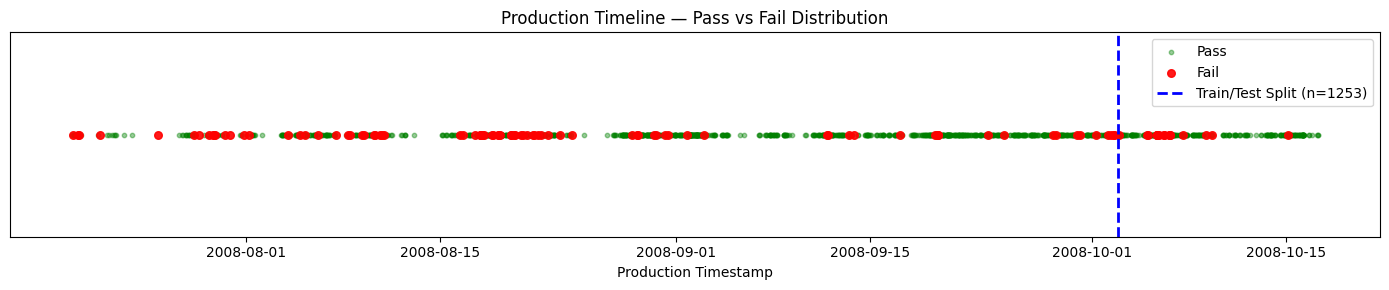

In [20]:
plt.figure(figsize=(14, 3))
plt.scatter(
    ts_sorted[y_sorted == -1],
    [0] * (y_sorted == -1).sum(),
    c='green', alpha=0.4, s=10, label='Pass'
)
plt.scatter(
    ts_sorted[y_sorted == 1],
    [0] * (y_sorted == 1).sum(),
    c='red', alpha=0.9, s=30, label='Fail'
)
plt.axvline(
    ts_sorted[split_point],
    color='blue', linestyle='--',
    linewidth=2, label=f'Train/Test Split (n={split_point})'
)
plt.xlabel('Production Timestamp')
plt.yticks([])
plt.title('Production Timeline — Pass vs Fail Distribution')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plots/p1_production_timeline.png', dpi=150)
plt.show()


In [21]:

print("=" * 52)
print("  PHASE 1 COMPLETE — DATA QUALITY REPORT")
print("=" * 52)
print(f"""
┌────────────────────────────────────────────────┐
│          SECOM CLEANING SUMMARY                │
├────────────────────────────────────────────────┤
│ Original features          : {features_start:<6}           │
│ Dropped (>50% missing)     : {len(cols_high_missing):<6}           │
│ Dropped (low variance)     : {len(cols_low_var):<6}           │
│ Dropped (high corr >0.95)  : {len(cols_high_corr):<6}           │
│ Final clean features       : {X_scaled.shape[1]:<6}           │
├────────────────────────────────────────────────┤
│ Total samples              : {len(X_scaled):<6}           │
│ TRAIN samples              : {len(X_train):<6}           │
│ TEST  samples              : {len(X_test):<6}           │
├────────────────────────────────────────────────┤
│ TRAIN fail rate            : {(y_train==1).mean():.2%}            │
│ TEST  fail rate            : {(y_test==1).mean():.2%}            │
├────────────────────────────────────────────────┤
│ Split      : Time-aware (no leakage)           │
│ Imputation : Median                            │
│ Scaling    : StandardScaler                    │
│ Imbalance  : class_weight='balanced'           │
│ SMOTE      : NOT used                          │
└────────────────────────────────────────────────┘
""")

  PHASE 1 COMPLETE — DATA QUALITY REPORT

┌────────────────────────────────────────────────┐
│          SECOM CLEANING SUMMARY                │
├────────────────────────────────────────────────┤
│ Original features          : 590              │
│ Dropped (>50% missing)     : 28               │
│ Dropped (low variance)     : 265              │
│ Dropped (high corr >0.95)  : 102              │
│ Final clean features       : 195              │
├────────────────────────────────────────────────┤
│ Total samples              : 1567             │
│ TRAIN samples              : 1253             │
│ TEST  samples              : 314              │
├────────────────────────────────────────────────┤
│ TRAIN fail rate            : 6.94%            │
│ TEST  fail rate            : 5.41%            │
├────────────────────────────────────────────────┤
│ Split      : Time-aware (no leakage)           │
│ Imputation : Median                            │
│ Scaling    : StandardScaler                    │

In [22]:
X_train.to_csv(f'{OUTPUT_DIR}/data/X_train.csv', index=False)
X_test.to_csv(f'{OUTPUT_DIR}/data/X_test.csv',   index=False)
y_train.to_csv(f'{OUTPUT_DIR}/data/y_train.csv', index=False)
y_test.to_csv(f'{OUTPUT_DIR}/data/y_test.csv',   index=False)
ts_train.to_csv(f'{OUTPUT_DIR}/data/ts_train.csv', index=False)
ts_test.to_csv(f'{OUTPUT_DIR}/data/ts_test.csv',   index=False)

X_full = X_scaled.copy()
X_full['label']     = y_sorted.values
X_full['timestamp'] = ts_sorted.values
X_full.to_csv(f'{OUTPUT_DIR}/data/secom_clean.csv', index=False)

pd.DataFrame({
    'feature_name':  X_scaled.columns,
    'feature_index': range(len(X_scaled.columns))
}).to_csv(f'{OUTPUT_DIR}/data/clean_feature_list.csv', index=False)

joblib.dump(scaler,  f'{OUTPUT_DIR}/models/scaler.pkl')
joblib.dump(imputer, f'{OUTPUT_DIR}/models/imputer.pkl')

print(" X_train.csv            saved")
print(" X_test.csv             saved")
print(" y_train.csv            saved")
print(" y_test.csv             saved")
print(" ts_train.csv           saved")
print(" ts_test.csv            saved")
print(" secom_clean.csv        saved")
print(" clean_feature_list.csv saved")
print(" scaler.pkl             saved")
print(" imputer.pkl            saved")


 X_train.csv            saved
 X_test.csv             saved
 y_train.csv            saved
 y_test.csv             saved
 ts_train.csv           saved
 ts_test.csv            saved
 secom_clean.csv        saved
 clean_feature_list.csv saved
 scaler.pkl             saved
 imputer.pkl            saved
